In [7]:
from langgraph.graph import StateGraph , START, END
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage, HumanMessage
# from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver 


In [8]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [9]:
# define nodes

llm = ChatGroq(
    groq_api_key='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', 
    model_name="llama-3.3-70b-versatile",
    temperature=0.5
)
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}


In [10]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node',chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot = graph.compile(checkpointer)

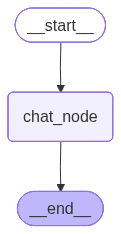

In [11]:
 chatbot

In [12]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

chatbot.invoke(initial_state)['messages'][-1].content

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
# thread_id ='1'

# while True:
#     user_message = input('Type here')
#     print('User' ,user_message)
#     if user_message.strip().lower() in ['exit','quit','bye']:
#         break

#     config ={'configurable':{'thread_id': thread_id}}
#     response =  chatbot.invoke({'messages':[HumanMessage(content=user_message)]},config=config)
#     print('AI:',response['messages'][-1].content)

In [13]:
thread_id = '1'

while True:
    user_message = input('Type here')
    print('User:', user_message)
    
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break
        
    config = {'configurable': {'thread_id': thread_id}}
    input_data = {'messages': [HumanMessage(content=user_message)]}
    
    print('AI: ', end="", flush=True) # Prepare to print tokens on one line
    
    # .stream() returns a generator
    for message, metadata in chatbot.stream(input_data, config, stream_mode="messages"):
        # We only want to print if the message is from the assistant/AI
        if message.content:
            print(message.content, end="", flush=True)
            
    print() # New line after the stream finishes

Type here write 100 line of blog about cricket


User: write 100 line of blog about cricket
Here's a 100-line blog about cricket:

1. Cricket is a sport that has been loved by millions of people around the world for centuries.
2. The game is played with a bat and ball, and the objective is to score runs by hitting the ball.
3. Cricket is a team sport, with two teams of eleven players each taking turns to bat and bowl.
4. The game is known for its unique rules and terminology, which can be confusing for beginners.
5. But once you understand the basics, cricket can be a thrilling and exciting sport to watch and play.
6. The game has a rich history, dating back to the 16th century in England.
7. Over time, cricket has evolved into different forms, including Test cricket, One-Day Internationals (ODIs), and Twenty20 (T20).
8. Each format has its own unique characteristics and challenges.
9. Test cricket is the longest form of the game, with matches lasting up to five days.
10. ODIs are limited to one day, with each team facing a limited n

Type here bye


User: bye
